# 📈 销量预测挑战 (Time Series Forecasting)

## 🎯 目标
从 "预测房价" (Regression) 进阶到 "预测未来" (Time Series)。我们将使用 Facebook 开源的神器 **Prophet** 来预测未来的销量趋势。

## 🧠 核心概念 (Concept Mapping)

为什么不能直接用 Linear Regression？
*   **普通回归**: 认为样本是独立的 (今天的房价和昨天的房价没关系，只看房子属性)。
*   **时间序列**: 认为时间有**惯性** (昨天的销量会影响今天) 和 **周期** (每个周末都比周一好)。

| 概念 | 解释 (SQL 类比) |
| :--- | :--- |
| **Trend (趋势)** | `ORDER BY date` 后的整体走向 (越来越好还是越来越差?) |
| **Seasonality (周期)** | `GROUP BY day_of_week` 发现的规律 (周五总是销量高?) |
| **Autocorrelation (自相关)** | `LAG(sales, 1)` 昨天的销量对今天的影响 |

## ⛽️ 函数加油站 (Function Cheat Sheet)

| 函数 | 作用 (大白话) | 常用参数 | SQL 类比 |
| :--- | :--- | :--- | :--- |
| `pd.to_datetime(df['ds'])` | **时间标准化**: 把字符串变成 Python 认识的时间 | `format='%Y-%m-%d'` | `CAST(col AS DATE)` |
| `Prophet()` | **请神**: 实例化 Prophet 模型 | `daily_seasonality=True` | `CREATE MODEL` |
| `m.fit(df)` | **修炼**: 喂数据给模型 | **必须要有 `ds` (时间) 和 `y` (数值) 两列!** | `TRAIN MODEL` |
| `m.make_future_dataframe()` | **造盒子**: 生成未来 N 天的空日期表 | `periods=30` (预测多少天) | 生成日期维表 |
| `m.predict(future)` | **填空**: 预测未来的值 | 返回的 `forecast` 包含 `yhat` (预测值) | `PREDICT` |
| `m.plot_components(forecast)` | **拆解**: 看看趋势和周期长啥样 | 无 | 自动生成可视化报表 |

In [1]:
# 🛠️ 模块 2: 数据准备 (Data Preparation)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet

# 必须安装 Prophet: !pip install prophet
# 如果报错 cmdstanpy，请尝试: !pip install prophet --upgrade

# 生成 365 天的模拟数据
np.random.seed(42)
dates = pd.date_range(start='2023-01-01', periods=365)

# 1. 基础趋势 (线性增长)
trend = np.linspace(0, 50, 365)

# 2. 周度周期 (周末生意好)
# dayofweek: 0=Mon, 6=Sun. 我们让 5,6 (周末) +20，其他 +0
seasonality = np.where(dates.dayofweek >= 5, 20, 0)

# 3. 噪声 (随机波动)
noise = np.random.normal(0, 5, 365)

# 合成最终销量
y = 100 + trend + seasonality + noise

# Prophet 严格要求列名必须是 'ds' 和 'y'
df = pd.DataFrame({'ds': dates, 'y': y})

print("数据已生成! 前5行:")
display(df.head())

## ⚔️ 挑战关卡 (Challenges)

In [2]:
# Level 1: 看看长啥样 (Visualization)
# 任务: 使用 matplotlib 画出 'ds' 和 'y' 的折线图，直观感受一下趋势。
# Hint: plt.plot(x, y)

# TODO: 写下你的代码
plt.plot(df['ds'], df['y'])

In [4]:
# === 参考答案 ===

# Level 1
plt.figure(figsize=(10, 6))
plt.plot(df['ds'], df['y'])
plt.title("Daily Sales Trend")
plt.show()

# Level 2
m = Prophet()
m.fit(df)
future = m.make_future_dataframe(periods=30)
forecast = m.predict(future)

# Level 3
fig = m.plot_components(forecast)
# 解释: 你应该能看到 Weekly 组件里，Saturday/Sunday 的柱子最高，这完美吻合我们 np.where(>=5, 20) 的逻辑。

## 🤯 Level 4 (Hardcore): 手撸特征工程 (XGBoost)

Prophet 是傻瓜式的，但面试官可能会问你：**"如果不许用 Prophet，只给你 XGBoost，怎么做时序预测？"**

**核心思想**: 把时序问题变成 **有监督回归问题 (Supervised Regression)**。

**我们需要手动构造特征 (Feature Engineering):**
1.  **Lags (滞后特征)**: 昨天的销量、前天的销量、上周的销量。
2.  **Rolling Window (滑动窗口)**: 过去7天的平均销量。
3.  **Date Features (日期特征)**: 是一周的第几天 (Monday=0)? 是几月份?

**挑战任务:**
1.  构造 `lag_1` (昨天), `lag_7` (上周今天)。
2.  构造 `rolling_mean_7` (过去7天均值)。
3.  使用 XGBoost 训练并预测。

In [ ]:
# 准备数据 (再次使用 df)
df_xgb = df.copy()
df_xgb.columns = ['date', 'sales']  # Prophet 叫 ds/y，我们改回来习惯的名字

# TODO: 构造特征
# 1. Lag Features (滞后)
df_xgb['lag_1'] = df_xgb['sales'].shift(1)
df_xgb['lag_7'] = df_xgb['sales'].shift(7)

# 2. Rolling Features (滑动平均)
# 注意: shift(1) 是为了防止由于包含“今天”的数据导致的穿越 (Leakage)
df_xgb['rolling_mean_7'] = df_xgb['sales'].shift(1).rolling(window=7).mean()

# 3. Date Features
df_xgb['day_of_week'] = df_xgb['date'].dt.dayofweek
df_xgb['month'] = df_xgb['date'].dt.month

# 4. 清洗空值 (Shift 会产生 NaN)
df_xgb = df_xgb.dropna()

print("特征构造完成! 前5行:")
display(df_xgb.head())

### 训练 & 评估 (Training & Evaluation)

In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 划分训练/测试集 (不能随机切分! 要按时间切!)
train_size = int(len(df_xgb) * 0.8)
train = df_xgb.iloc[:train_size]
test = df_xgb.iloc[train_size:]

features = ['lag_1', 'lag_7', 'rolling_mean_7', 'day_of_week', 'month']
target = 'sales'

X_train, y_train = train[features], train[target]
X_test, y_test = test[features], test[target]

# 训练模型
# ⚠️ 注意: early_stopping_rounds 必须在实例化时指定 (XGBoost新版API变更)
model = xgb.XGBRegressor(n_estimators=1000, learning_rate=0.01, early_stopping_rounds=50)
model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)

# 预测
prediction = model.predict(X_test)

# === 核心评估 (Evaluation) ===
# Q: 怎么看模型好坏？回归问题看什么？
# A: 
# 1. MAE (平均绝对误差): "平均预测偏了多少？" -> 最好解释给老板听
# 2. RMSE (均方根误差): "对大误差敏感吗？" -> 出现极端值时 RMSE 会很大

mae = mean_absolute_error(y_test, prediction)
rmse = np.sqrt(mean_squared_error(y_test, prediction))

print(f"MAE (Average Error): {mae:.2f}")
print(f"RMSE (Peak Sensitivity): {rmse:.2f}")

# 残差分析 (Residual Analysis)
# 残差 = 真实值 - 预测值
residuals = y_test - prediction

# 可资化对比
plt.figure(figsize=(10, 5))
plt.plot(test['date'], test['sales'], label='True Sales')
plt.plot(test['date'], prediction, label='XGBoost Prediction', linestyle='--')
plt.legend()
plt.title(f"XGBoost Prediction (MAE: {mae:.2f})")
plt.show()

import seaborn as sns
plt.figure(figsize=(10, 4))
plt.plot(test['date'], residuals)
plt.axhline(0, color='r', linestyle='--')
plt.title("Residuals (Errors) Over Time")
plt.ylabel("Error")
plt.show()

plt.figure(figsize=(6, 4))
sns.histplot(residuals, kde=True)
plt.title("Distribution of Residuals")
plt.show()

## 👑 Level 5: The Pro Move - Differencing (差分)

你可能会发现，XGBoost 在预测**长期增长趋势**时表现不如 Prophet。为什么？

**根本原因**: 树模型 (Tree-based models) **不能外推 (Extrapolate)**！
*   如果训练数据的销量最高是 200，XGBoost 永远不敢预测出 250。它只能在见过的范围内做平均。
*   随着时间推移，如果销量一直涨，XGBoost 会"跟不上"，导致预测值一直偏低 (Systematic Underestimation)。

**解决方案: 差分 (Differencing)**
我们不预测 "今天的销量是多少" ($y_t$)，而是预测 **"今天比昨天多了多少"** ($y_t - y_{t-1}$)。
*   这个差值通常是在一个稳定区间的（比如每天多卖 0~5 个），这是树模型最擅长的！
*   预测完差值后，再把昨天的真实销量加回去，就得到了今天的预测值。

> **💡 思考题**: 上面我们犯了一个严重的**数据泄露 (Data Leakage)** 错误，导致 MAE 极低 (0.25)。你能看出来吗？
> **答案**: 我们把 Target(`diff_lag_1`) 放进了 Feature 列表里！这等于是告诉模型答案。
> **正确做法**: 预测 $Difference_t$，Feature 只能用 $Difference_{t-1}, Difference_{t-7}$ 等滞后项。

In [10]:
# Level 5: 正确的差分预测 (Correct Implementation)

# 1. 构造差分目标 (Target)
# 我们要预测的是: 今天 - 昨天 (Growth)
df_diff = df.copy()
df_diff.columns = ['date', 'sales']

# target_diff = sales_t - sales_{t-1}
df_diff['target_diff'] = df_diff['sales'].diff()

# 2. 构造基于差分的特征 (Features based on Diff)
# ❌ 错误做法: 直接用 sales - sales.shift(7)，这其实包含了 sales_t 的信息(如果是预测未来，你不知道今天的sales)
# ✅ 正确做法: 使用 target_diff 的滞后项 (Lag of Diff)

# 昨天的增长量 (Predictor)
df_diff['diff_lag_1'] = df_diff['target_diff'].shift(1)
# 上周今天的增长量
df_diff['diff_lag_7'] = df_diff['target_diff'].shift(7)
# 过去7天平均增长量
df_diff['diff_rolling_mean_7'] = df_diff['target_diff'].shift(1).rolling(window=7).mean()

# 辅助时间特征
df_diff['day_of_week'] = df_diff['date'].dt.dayofweek
df_diff['month'] = df_diff['date'].dt.month

# 去除空值 (因为 shift 会产生 NaN)
df_diff = df_diff.dropna()

print("特征构造完成 (注意看 target_diff 和 diff_lag_1 是错位的):")
display(df_diff.head())

特征构造完成 (注意看 target_diff 和 diff_lag_1 是错位的):


,date,sales,target_diff,diff_lag_1,diff_lag_7,diff_rolling_mean_7,day_of_week,month
8,2023-01-09,98.751529,-26.047183,-3.921528,-23.037530,0.330734,0,1
9,2023-01-10,103.949064,5.197535,-26.047183,4.067127,-0.099216,1,1
10,2023-01-11,99.056538,-4.892526,5.197535,4.514069,0.062271,2,1
11,2023-01-12,99.182340,0.125802,-4.892526,-8.648554,-1.281528,3,1
12,2023-01-13,102.858163,3.675823,0.125802,0.137445,-0.028049,4,1


(Reconstructed) MAE: 3.89
(Reconstructed) RMSE: 4.68


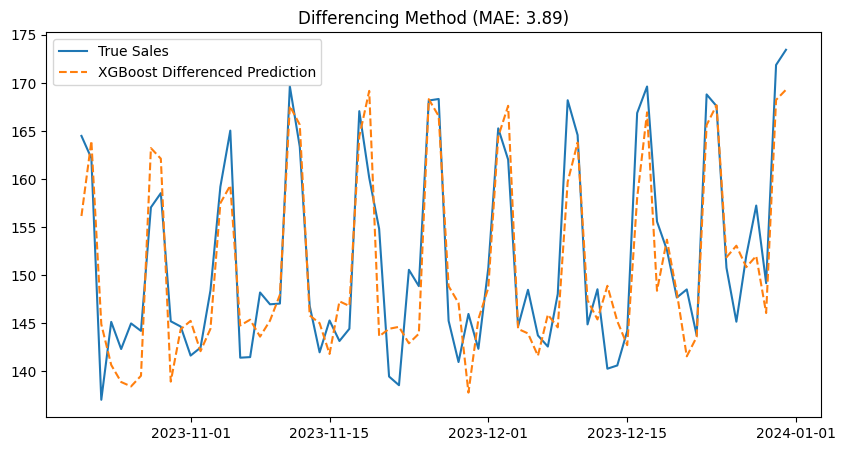

In [11]:
# 划分数据集
train_size = int(len(df_diff) * 0.8)
train = df_diff.iloc[:train_size]
test = df_diff.iloc[train_size:]

# ❌ 特征里绝对不能包含 'target_diff' 和 'sales'
features = ['diff_lag_1', 'diff_lag_7', 'diff_rolling_mean_7', 'day_of_week', 'month']
target = 'target_diff'

X_train, y_train = train[features], train[target]
X_test, y_test = test[features], test[target]

# 训练
model_diff = xgb.XGBRegressor(n_estimators=1000, learning_rate=0.01, early_stopping_rounds=50)
model_diff.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)

# 预测 (得到的是增长量 Predicted Growth)
pred_diff = model_diff.predict(X_test)

# === 还原 (Reconstruction) ===
# 预测值(t) = 真实值(t-1) + 预测增长量(t)
# 注意: 在实际预测未来时，真实值(t-1)也是未知的(如果是多步预测)，这里单步预测我们用测试集的 lag_sales

# 我们需要拿回昨天的真实销量来还原
# test 数据集的 'sales' 是今天的真实值。我们需要 shift(1) 得到昨天的真实值。
# 但注意 df_diff 已经是切片过的，直接 shift 可能会丢失第一行之前的那个数据。
# 最稳妥的方法是直接从原始 df 里找对应日期的昨天销量。
# 简便方法: test['sales'] - test['target_diff'] = 昨天的真实销量

prev_day_sales = test['sales'] - test['target_diff']
pred_sales = prev_day_sales + pred_diff

# 评估还原后的绝对值误差
mae = mean_absolute_error(test['sales'], pred_sales)
rmse = np.sqrt(mean_squared_error(test['sales'], pred_sales))

print(f"(Reconstructed) MAE: {mae:.2f}")
print(f"(Reconstructed) RMSE: {rmse:.2f}")

# 可视化
plt.figure(figsize=(10, 5))
plt.plot(test['date'], test['sales'], label='True Sales')
plt.plot(test['date'], pred_sales, label='XGBoost Differenced Prediction', linestyle='--')
plt.legend()
plt.title(f"Differencing Method (MAE: {mae:.2f})")
plt.show()

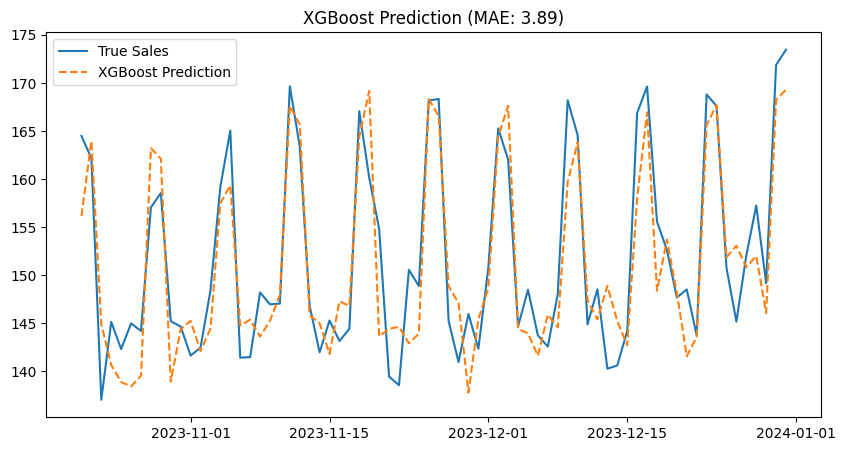

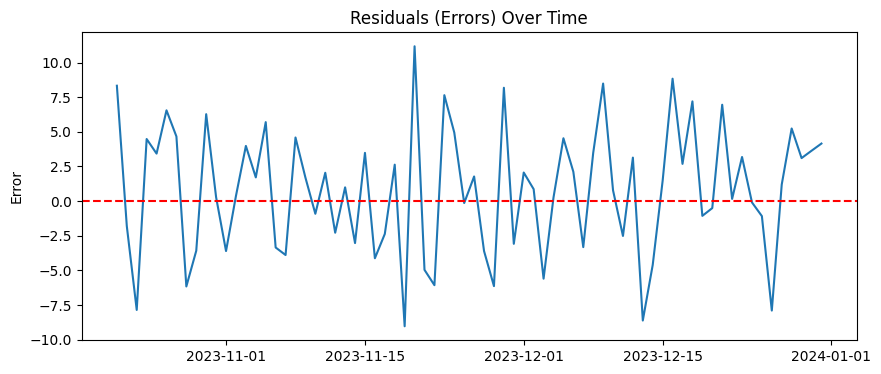

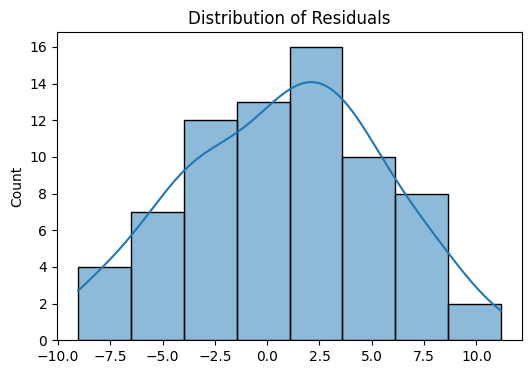

In [12]:
# 残差分析 (Residual Analysis)
# 残差 = 真实值 - 预测值
residuals = test['sales'] - pred_sales

# 可资化对比
plt.figure(figsize=(10, 5))
plt.plot(test['date'], test['sales'], label='True Sales')
plt.plot(test['date'], pred_sales, label='XGBoost Prediction', linestyle='--')
plt.legend()
plt.title(f"XGBoost Prediction (MAE: {mae:.2f})")
plt.show()

import seaborn as sns
plt.figure(figsize=(10, 4))
plt.plot(test['date'], residuals)
plt.axhline(0, color='r', linestyle='--')
plt.title("Residuals (Errors) Over Time")
plt.ylabel("Error")
plt.show()

plt.figure(figsize=(6, 4))
sns.histplot(residuals, kde=True)
plt.title("Distribution of Residuals")
plt.show()

In [ ]:
# ## 🛡️ Level 6: 交叉验证 (Time Series Cross-Validation)
#
# **Q: 既然有了 Train/Test Split，为什么还要做交叉验证？**
# A: 一次切分可能只是“运气好”。也许你的模型只在2023年12月表现好，但在1月表现很差？
# **Time Series Split** 就像“时间的滑动窗口”：
# *   第1次: 训练 [1月], 验证 [2月]
# *   第2次: 训练 [1-2月], 验证 [3月]
# *   第3次: 训练 [1-3月], 验证 [4月]
# *   ...
# 这样能检测模型在**不同时期**的稳定性 (Robustness)。

from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)
print(f"开始进行 {tscv.n_splits} 折交叉验证...")

fold = 0
mae_scores = []
rmse_scores = []

# 重置索引，方便切分
df_diff_cv = df_diff.reset_index(drop=True)

features_cv = ['diff_lag_1', 'diff_lag_7', 'diff_rolling_mean_7', 'day_of_week', 'month']
target_cv = 'target_diff'

for train_index, test_index in tscv.split(df_diff_cv):
    fold += 1
    cv_train = df_diff_cv.iloc[train_index]
    cv_test = df_diff_cv.iloc[test_index]
    
    # 训练模型
    cv_model = xgb.XGBRegressor(n_estimators=1000, learning_rate=0.01, early_stopping_rounds=50)
    
    # 注意: 这里 fit 时 evaluation set 只用来 early stopping，不应该用来作为最终分数的依据
    cv_model.fit(cv_train[features_cv], cv_train[target_cv], 
                 eval_set=[(cv_train[features_cv], cv_train[target_cv]), (cv_test[features_cv], cv_test[target_cv])], 
                 verbose=False)
    
    # 预测差分
    diff_pred = cv_model.predict(cv_test[features_cv])
    
    # (重要) 还原: 真实值 = 昨天的真实销量 + 预测的差分
    y_true_abs = cv_test['sales'] # 今天的真实销量(绝对值)
    y_last_abs = cv_test['sales'].shift(1) # 昨天的真实销量(绝对值)
    
    # 填补 shift 产生的第一个 NaN (用 cv_train 的最后一个值)
    if np.isnan(y_last_abs.iloc[0]):
        y_last_abs.iloc[0] = cv_train.iloc[-1]['sales']
        
    y_pred_abs = y_last_abs + diff_pred
    
    # 计算误差
    fold_mae = mean_absolute_error(y_true_abs, y_pred_abs)
    fold_rmse = np.sqrt(mean_squared_error(y_true_abs, y_pred_abs))
    
    mae_scores.append(fold_mae)
    rmse_scores.append(fold_rmse)
    
    print(f"Fold {fold}: MAE = {fold_mae:.4f}, RMSE = {fold_rmse:.4f}")

print(f"\n平均 MAE: {np.mean(mae_scores):.4f} (+/- {np.std(mae_scores):.4f})")
print(f"平均 RMSE: {np.mean(rmse_scores):.4f} (+/- {np.std(rmse_scores):.4f})")

In [ ]:
# ## 🔬 Level 6 Pro: 敏感性/鲁棒性检验 (Sensitivity/Robustness Check)
#
# **Q: 我们的模型是不是“玻璃心”？(Sensitivity)**
# A: 如果数据稍微有一点点噪音，预测结果会不会直接崩掉？
#
# **测试方法 (Perturbation Test):**
# 给输入特征通过人为添加微小的 **随机噪音 (Noise)**，看看预测结果会有多大变化。
# *   如果变化很小 -> 模型鲁棒 (Robust)
# *   如果变化巨大 -> 模型过拟合或不稳定 (Sensitive)

# 1. 使用最后一轮Fold的模型 (cv_model) 和测试集 (cv_test)
# 2. 原始预测
robust_diff_pred = cv_model.predict(cv_test[features_cv])

# 3. 给特征 'diff_lag_1' (昨天增长) 添加 5% 的随机噪音
cv_test_noisy = cv_test.copy()
noise_level = 0.05
noise = np.random.normal(0, cv_test_noisy['diff_lag_1'].std() * noise_level, len(cv_test_noisy))
cv_test_noisy['diff_lag_1'] += noise

# 4. 噪音预测
robust_diff_pred_noisy = cv_model.predict(cv_test_noisy[features_cv])

# 5. 比较变化率
change_rate = np.mean(np.abs(robust_diff_pred - robust_diff_pred_noisy) / (np.abs(robust_diff_pred) + 1e-6))
print(f"输入特征增加 {noise_level*100}% 噪音后，预测结果平均变化率: {change_rate*100:.2f}%")

if change_rate < 0.1:
    print("✅ 模型表现极其稳定 (Very Robust)！")
else:
    print("⚠️ 模型对噪音较敏感，需要检查是否过拟合。")